In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Fundamentals and Baseline Model

In [ ]:
import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/content/drive/MyDrive/FINRISK_360"
CLEANING_DIR = os.path.join(PROJECT_DIR, "Cleaning")

PATH = os.path.join(
    CLEANING_DIR,
    "credit_risk_fully_feature_engineered.csv"
)

print("Checkpoint exists:", os.path.exists(PATH))
print("Checkpoint path:", PATH)

Checkpoint exists: True
Checkpoint path: /content/drive/MyDrive/FINRISK_360/Cleaning/credit_risk_fully_feature_engineered.csv


In [ ]:
df = pd.read_csv(PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (32416, 33)


### Target

In [ ]:
print("Target column exists:", "loan_status" in df.columns)

print("\nTarget distribution:")
display(
    df["loan_status"]
    .value_counts()
    .sort_index()
)

print("\nTarget proportions:")
display(
    df["loan_status"]
    .value_counts(normalize=True)
    .sort_index()
)

Target column exists: True

Target distribution:


,count
loan_status,
0,25327
1,7089



Target proportions:


,proportion
loan_status,
0,0.781312
1,0.218688


### Check for obvious target leakage

In [ ]:
leakage_like_columns = [
    col for col in df.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "target",
            "default_status",
            "outcome",
            "label",
            "loan_status"
        ]
    )
]

print("Potential target/leakage-related columns:")
for col in leakage_like_columns:
    print(col)

Potential target/leakage-related columns:
loan_status


### Define the intended model features

In [ ]:
numeric_features = [
    "person_income_scaled",
    "loan_amnt_scaled",
    "loan_int_rate_scaled",
    "person_age_scaled",
    "person_emp_length_scaled",
    "cb_person_cred_hist_length_scaled"
]

In [ ]:
derived_features = [
    "loan_percent_income",
    "grade_burden_interaction",
    "employment_stability_flag",
    "loan_grade_encoded",
    "cb_person_default_on_file_encoded"
]

In [ ]:
one_hot_features = [
    col for col in df.columns
    if col.startswith("loan_intent_")
]

In [ ]:
home_ownership_features = [
    col for col in df.columns
    if col.startswith("home_ownership_")
]

In [ ]:
credit_history_features = [
    col for col in df.columns
    if col.startswith("credit_history_depth_")
    and col != "credit_history_depth_tier"
]

In [ ]:
model_features = (
    numeric_features
    + derived_features
    + one_hot_features
    + home_ownership_features
    + credit_history_features
)

print("Number of model features:", len(model_features))

print("\nModel features:")
for i, col in enumerate(model_features, start=1):
    print(f"{i:2d}. {col}")

Number of model features: 19

Model features:
 1. person_income_scaled
 2. loan_amnt_scaled
 3. loan_int_rate_scaled
 4. person_age_scaled
 5. person_emp_length_scaled
 6. cb_person_cred_hist_length_scaled
 7. loan_percent_income
 8. grade_burden_interaction
 9. employment_stability_flag
10. loan_grade_encoded
11. cb_person_default_on_file_encoded
12. loan_intent_EDUCATION
13. loan_intent_HOMEIMPROVEMENT
14. loan_intent_MEDICAL
15. loan_intent_PERSONAL
16. loan_intent_VENTURE
17. home_ownership_OTHER
18. home_ownership_OWN
19. home_ownership_RENT


In [ ]:
from sklearn.preprocessing import StandardScaler
import os
import joblib

# Six numeric variables selected for scaling
numeric_features = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "person_age",
    "person_emp_length",
    "cb_person_cred_hist_length"
]

# Create the scaler
scaler = StandardScaler()

# Fit and transform the six numeric variables
scaled_values = scaler.fit_transform(df[numeric_features])

# Create the scaled columns
for i, col in enumerate(numeric_features):
    df[f"{col}_scaled"] = scaled_values[:, i]

print("Scaled features created successfully.")

Scaled features created successfully.


In [ ]:
missing_model_features = [
    col for col in model_features
    if col not in df.columns
]

if missing_model_features:
    print("Missing model features:")
    for col in missing_model_features:
        print("-", col)
else:
    print("All expected model features are present.")

All expected model features are present.


### Build the Preliminary X and y

In [ ]:
X_pre = df[model_features].copy()
y = df["loan_status"].copy()

print("X shape:", X_pre.shape)
print("y shape:", y.shape)

X shape: (32416, 19)
y shape: (32416,)


### Check for target leakage explicitly

In [ ]:
print("Is loan_status in X?", "loan_status" in X_pre.columns)

Is loan_status in X? False


### Multicollinearity Resolution

The correlation analysis identified a strong correlation between:

- `person_age_scaled`
- `cb_person_cred_hist_length_scaled`

The correlation between the two features was **r = 0.88**, indicating strong multicollinearity.

### Decision

- **Dropped:** `person_age_scaled`
- **Retained:** `cb_person_cred_hist_length_scaled`

### Reason

For the interpretable baseline Logistic Regression model, `person_age_scaled` was removed to reduce multicollinearity. `cb_person_cred_hist_length_scaled` was retained because **credit-history length is more directly relevant to credit risk** and provides a more risk-specific interpretation.

**Final decision:** Retain `cb_person_cred_hist_length_scaled` and remove `person_age_scaled`.

#### Create the final baseline feature list

In [ ]:
# Remove the highly correlated age feature
baseline_features = [
    col for col in model_features
    if col != "person_age_scaled"
]

print("Original number of model features:", len(model_features))
print("Baseline number of features:", len(baseline_features))

print("\nRemoved feature:")
print("person_age_scaled")

print("\nRetained correlated feature:")
print("cb_person_cred_hist_length_scaled")

Original number of model features: 19
Baseline number of features: 18

Removed feature:
person_age_scaled

Retained correlated feature:
cb_person_cred_hist_length_scaled


### Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Create X and y
X = df[baseline_features].copy()
y = df["loan_status"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

X shape: (32416, 18)
y shape: (32416,)
Train shape: (25932, 18)
Test shape: (6484, 18)
Train target shape: (25932,)
Test target shape: (6484,)


#### Verify Stratification

In [ ]:
split_summary = pd.DataFrame({
    "Dataset": ["Overall", "Train", "Test"],
    "Applications": [
        len(y),
        len(y_train),
        len(y_test)
    ],
    "Defaults": [
        y.sum(),
        y_train.sum(),
        y_test.sum()
    ],
    "Default_Rate_Percent": [
        y.mean() * 100,
        y_train.mean() * 100,
        y_test.mean() * 100
    ]
})

display(split_summary)

,Dataset,Applications,Defaults,Default_Rate_Percent
0,Overall,32416,7089,21.868830
1,Train,25932,5671,21.868734
2,Test,6484,1418,21.869217


### Train the Logistic Regression baseline

#### Import Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

#### Create the model

In [ ]:
logistic_baseline = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=1000
)

#### Train the model

In [ ]:
logistic_baseline.fit(X_train, y_train)

print("Logistic Regression baseline trained successfully.")

Logistic Regression baseline trained successfully.


#### Generate predictions

In [ ]:
y_pred = logistic_baseline.predict(X_test)

In [ ]:
y_prob = logistic_baseline.predict_proba(X_test)[:, 1]

#### Record Baseline Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate all five metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# Baseline Results
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression — Baseline"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "ROC_AUC": [roc_auc]
})

baseline_results_percent = baseline_results.copy()

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]:
    baseline_results_percent[metric] = (
        baseline_results_percent[metric] * 100
    )

display(baseline_results_percent)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression — Baseline,78.855645,51.07355,78.843441,61.990574,86.731617


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3995 1071]
 [ 300 1118]]


### Save the results

In [ ]:
BASE_MODEL_RESULTS_PATH = os.path.join(
    PROJECT_DIR,
    "Checkpoints",
    "logistic_regression_baseline_results.csv"
)

baseline_results.to_csv(
    BASE_MODEL_RESULTS_PATH,
    index=False
)

print("Baseline results saved to:")
print(BASE_MODEL_RESULTS_PATH)

Baseline results saved to:
/content/drive/MyDrive/FINRISK_360/Checkpoints/logistic_regression_baseline_results.csv


In [ ]:
confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual_Non_Default", "Actual_Default"],
    columns=["Predicted_Non_Default", "Predicted_Default"]
)

CM_PATH = os.path.join(
    PROJECT_DIR,
    "Checkpoints",
    "logistic_regression_baseline_confusion_matrix.csv"
)

confusion_matrix_df.to_csv(
    CM_PATH
)

print("Confusion matrix saved to:")
print(CM_PATH)

Confusion matrix saved to:
/content/drive/MyDrive/FINRISK_360/Checkpoints/logistic_regression_baseline_confusion_matrix.csv


## Random Forest

In [ ]:
import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/content/drive/MyDrive/FINRISK_360"
CLEANING_DIR = os.path.join(PROJECT_DIR, "Cleaning")

FEATURE_PATH = os.path.join(
    CLEANING_DIR,
    "credit_risk_fully_feature_engineered.csv"
)

print("Checkpoint exists:", os.path.exists(FEATURE_PATH))

df = pd.read_csv(FEATURE_PATH)

print("Dataset shape:", df.shape)

Checkpoint exists: True
Dataset shape: (32416, 33)


### Build the Random Forest Feature Set

In [ ]:
rf_numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

In [ ]:
rf_derived_features = [
    "age_invalid_flag",
    "emp_length_invalid_flag",
    "emp_length_missing_flag",
    "loan_int_rate_missing_flag",
    "loan_grade_encoded",
    "cb_person_default_on_file_encoded",
    "grade_burden_interaction",
    "employment_stability_flag"
]

In [ ]:
rf_one_hot_features = [
    col for col in df.columns
    if col.startswith("loan_intent_")
    or col.startswith("home_ownership_")
]

In [ ]:
rf_credit_history_features = [
    col for col in df.columns
    if col.startswith("credit_history_depth_")
    and col != "credit_history_depth_tier"
]

In [ ]:
rf_features = (
    rf_numeric_features
    + rf_derived_features
    + rf_one_hot_features
    + rf_credit_history_features
)

print("Number of Random Forest features:", len(rf_features))

print("\nRandom Forest features:")
for i, col in enumerate(rf_features, start=1):
    print(f"{i:2d}. {col}")

Number of Random Forest features: 23

Random Forest features:
 1. person_age
 2. person_income
 3. person_emp_length
 4. loan_amnt
 5. loan_int_rate
 6. loan_percent_income
 7. cb_person_cred_hist_length
 8. age_invalid_flag
 9. emp_length_invalid_flag
10. emp_length_missing_flag
11. loan_int_rate_missing_flag
12. loan_grade_encoded
13. cb_person_default_on_file_encoded
14. grade_burden_interaction
15. employment_stability_flag
16. loan_intent_EDUCATION
17. loan_intent_HOMEIMPROVEMENT
18. loan_intent_MEDICAL
19. loan_intent_PERSONAL
20. loan_intent_VENTURE
21. home_ownership_OTHER
22. home_ownership_OWN
23. home_ownership_RENT


### Validate the Feature Set

In [ ]:
missing_rf_features = [
    col for col in rf_features
    if col not in df.columns
]

print("Missing RF features:", missing_rf_features)

print(
    "\nTarget included in RF features:",
    "loan_status" in rf_features
)

non_numeric_rf = (
    df[rf_features]
    .select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)

print("\nNon-numeric RF features:", non_numeric_rf)

Missing RF features: []

Target included in RF features: False

Non-numeric RF features: []


### Create X and y

In [ ]:
X_rf = df[rf_features].copy()
y_rf = df["loan_status"].copy()

print("X shape:", X_rf.shape)
print("y shape:", y_rf.shape)

print("Missing values in X:", X_rf.isna().sum().sum())
print("Missing values in y:", y_rf.isna().sum())

X shape: (32416, 23)
y shape: (32416,)
Missing values in X: 0
Missing values in y: 0


### Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf,
    y_rf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_rf
)

print("RF train shape:", X_rf_train.shape)
print("RF test shape:", X_rf_test.shape)

print("\nTrain default rate:", y_rf_train.mean())
print("Test default rate:", y_rf_test.mean())

RF train shape: (25932, 23)
RF test shape: (6484, 23)

Train default rate: 0.2186873361098257
Test default rate: 0.21869216533004318


### Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_baseline.fit(
    X_rf_train,
    y_rf_train
)

print("Random Forest baseline trained successfully.")

Random Forest baseline trained successfully.


### Generate Random Forest predictions

In [ ]:
rf_pred = rf_baseline.predict(X_rf_test)

rf_prob = rf_baseline.predict_proba(
    X_rf_test
)[:, 1]

print("Predictions generated.")

Predictions generated.


### Evaluate Random Forest

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(
    y_rf_test,
    rf_pred
)

rf_precision = precision_score(
    y_rf_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_rf_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_rf_test,
    rf_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_rf_test,
    rf_prob
)

rf_results = pd.DataFrame({
    "Model": ["Random Forest — Baseline"],
    "Accuracy": [rf_accuracy],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "F1": [rf_f1],
    "ROC_AUC": [rf_roc_auc]
})

display(rf_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest — Baseline,0.932603,0.967588,0.715797,0.822862,0.930652


## XGBoost

### Calculate the actual class ratio

In [ ]:
negative_count = (y_rf_train == 0).sum()
positive_count = (y_rf_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class count:", negative_count)
print("Positive class count:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative class count: 20261
Positive class count: 5671
scale_pos_weight: 3.5727384940927527


### Train the XGBoost Baseline

In [ ]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_baseline.fit(
    X_rf_train,
    y_rf_train
)

print("XGBoost baseline trained successfully.")

XGBoost baseline trained successfully.


### Generate XGBoost Predictions

In [ ]:
xgb_pred = xgb_baseline.predict(X_rf_test)

xgb_prob = xgb_baseline.predict_proba(
    X_rf_test
)[:, 1]

print("XGBoost predictions generated.")

XGBoost predictions generated.


### Evaluate XGBoost

In [ ]:
xgb_accuracy = accuracy_score(
    y_rf_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_rf_test,
    xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_rf_test,
    xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_rf_test,
    xgb_pred,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_rf_test,
    xgb_prob
)

xgb_results = pd.DataFrame({
    "Model": ["XGBoost - Baseline"],
    "Accuracy": [xgb_accuracy],
    "Precision": [xgb_precision],
    "Recall": [xgb_recall],
    "F1": [xgb_f1],
    "ROC_AUC": [xgb_roc_auc]
})

display(xgb_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost - Baseline,0.909932,0.799139,0.785614,0.792319,0.94093


## Hyperparameter Tuning

### Random Forest Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_leaf": [1, 2]
}

rf_tuning = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_tuning.fit(
    X_rf_train,
    y_rf_train
)

print("Best Random Forest parameters:")
print(rf_tuning.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(rf_tuning.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}

Best cross-validation ROC-AUC:
0.9285964071508301


#### Evaluate Tuned Random Forest

In [ ]:
rf_tuned = rf_tuning.best_estimator_

rf_tuned_pred = rf_tuned.predict(X_rf_test)

rf_tuned_prob = rf_tuned.predict_proba(
    X_rf_test
)[:, 1]

rf_tuned_results = pd.DataFrame({
    "Model": ["Random Forest — Tuned"],
    "Accuracy": [
        accuracy_score(y_rf_test, rf_tuned_pred)
    ],
    "Precision": [
        precision_score(
            y_rf_test,
            rf_tuned_pred,
            zero_division=0
        )
    ],
    "Recall": [
        recall_score(
            y_rf_test,
            rf_tuned_pred,
            zero_division=0
        )
    ],
    "F1": [
        f1_score(
            y_rf_test,
            rf_tuned_pred,
            zero_division=0
        )
    ],
    "ROC_AUC": [
        roc_auc_score(
            y_rf_test,
            rf_tuned_prob
        )
    ]
})

display(rf_tuned_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest — Tuned,0.928439,0.930505,0.72708,0.81631,0.92931


### XGBoost Tuning

In [ ]:
xgb_param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.10],
    "n_estimators": [100, 200]
}

xgb_tuning = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

xgb_tuning.fit(
    X_rf_train,
    y_rf_train
)

print("Best XGBoost parameters:")
print(xgb_tuning.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(xgb_tuning.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGBoost parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Best cross-validation ROC-AUC:
0.944492747813244


#### Evaluate Tuned XGBoost

In [ ]:
xgb_tuned = xgb_tuning.best_estimator_

xgb_tuned_pred = xgb_tuned.predict(X_rf_test)

xgb_tuned_prob = xgb_tuned.predict_proba(
    X_rf_test
)[:, 1]

xgb_tuned_results = pd.DataFrame({
    "Model": ["XGBoost — Tuned"],
    "Accuracy": [
        accuracy_score(y_rf_test, xgb_tuned_pred)
    ],
    "Precision": [
        precision_score(
            y_rf_test,
            xgb_tuned_pred,
            zero_division=0
        )
    ],
    "Recall": [
        recall_score(
            y_rf_test,
            xgb_tuned_pred,
            zero_division=0
        )
    ],
    "F1": [
        f1_score(
            y_rf_test,
            xgb_tuned_pred,
            zero_division=0
        )
    ],
    "ROC_AUC": [
        roc_auc_score(
            y_rf_test,
            xgb_tuned_prob
        )
    ]
})

display(xgb_tuned_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost — Tuned,0.920111,0.827511,0.801834,0.81447,0.948682


## Model Comparison Table

In [ ]:
model_comparison = pd.concat(
    [
        baseline_results,
        rf_results,
        xgb_results,
        rf_tuned_results,
        xgb_tuned_results
    ],
    ignore_index=True
)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression — Baseline,0.788556,0.510735,0.788434,0.619906,0.867316
1,Random Forest — Baseline,0.932603,0.967588,0.715797,0.822862,0.930652
2,XGBoost - Baseline,0.909932,0.799139,0.785614,0.792319,0.940930
3,Random Forest — Tuned,0.928439,0.930505,0.727080,0.816310,0.929310
4,XGBoost — Tuned,0.920111,0.827511,0.801834,0.814470,0.948682


## Extract built-in feature importance

### Random Forest feature importance

In [ ]:
rf_importance = pd.DataFrame({
    "feature": rf_features,
    "importance": rf_tuned.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 Random Forest features:")
display(rf_importance.head(20))

Top 20 Random Forest features:


,feature,importance
0,grade_burden_interaction,0.168362
1,loan_percent_income,0.149285
2,person_income,0.132812
3,loan_int_rate,0.106146
4,loan_grade_encoded,0.104426
5,loan_amnt,0.066786
6,home_ownership_RENT,0.055000
7,person_emp_length,0.041172
8,person_age,0.039372
9,cb_person_cred_hist_length,0.031282


### XGBoost Feature Importance

In [ ]:
xgb_importance = pd.DataFrame({
    "feature": rf_features,
    "importance": xgb_tuned.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 XGBoost features:")
display(xgb_importance.head(20))

Top 20 XGBoost features:


,feature,importance
0,loan_grade_encoded,0.145888
1,grade_burden_interaction,0.119589
2,home_ownership_RENT,0.111499
3,home_ownership_OWN,0.096221
4,loan_percent_income,0.067306
5,loan_intent_VENTURE,0.064934
6,person_income,0.052928
7,loan_intent_HOMEIMPROVEMENT,0.049688
8,employment_stability_flag,0.037728
9,loan_intent_PERSONAL,0.034029


## Model Evaluation and Selection

In [ ]:
objects_to_check = [
    "logistic_baseline",
    "rf_baseline",
    "xgb_baseline",
    "rf_tuned",
    "xgb_tuned",
    "y_test",
    "y_pred",
    "y_prob",
    "rf_tuned_pred",
    "rf_tuned_prob",
    "xgb_tuned_pred",
    "xgb_tuned_prob"
]

for obj in objects_to_check:
    print(f"{obj}: {'Available' if obj in globals() else 'Missing'}")

logistic_baseline: Available
rf_baseline: Available
xgb_baseline: Available
rf_tuned: Available
xgb_tuned: Available
y_test: Available
y_pred: Available
y_prob: Available
rf_tuned_pred: Available
rf_tuned_prob: Available
xgb_tuned_pred: Available
xgb_tuned_prob: Available


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }

In [ ]:
logistic_eval = evaluate_classifier(
    "Logistic Regression",
    y_test,
    y_pred,
    y_prob
)

rf_eval = evaluate_classifier(
    "Random Forest",
    y_rf_test,
    rf_tuned_pred,
    rf_tuned_prob
)

xgb_eval = evaluate_classifier(
    "XGBoost",
    y_rf_test,
    xgb_tuned_pred,
    xgb_tuned_prob
)

comparison_table = pd.DataFrame([
    logistic_eval,
    rf_eval,
    xgb_eval
])

display(comparison_table)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.788556,0.510735,0.788434,0.619906,0.867316
1,Random Forest,0.928439,0.930505,0.727080,0.816310,0.929310
2,XGBoost,0.920111,0.827511,0.801834,0.814470,0.948682


In [ ]:
comparison_percent = comparison_table.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

for col in metric_columns:
    comparison_percent[col] = (
        comparison_percent[col] * 100
    )

display(
    comparison_percent.round(2)
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,78.86,51.07,78.84,61.99,86.73
1,Random Forest,92.84,93.05,72.71,81.63,92.93
2,XGBoost,92.01,82.75,80.18,81.45,94.87


In [ ]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred
)

cm_rf = confusion_matrix(
    y_rf_test,
    rf_tuned_pred
)

cm_xgb = confusion_matrix(
    y_rf_test,
    xgb_tuned_pred
)

print("Logistic Regression:")
print(cm_logistic)

print("\nRandom Forest:")
print(cm_rf)

print("\nXGBoost:")
print(cm_xgb)

Logistic Regression:
[[3995 1071]
 [ 300 1118]]

Random Forest:
[[4989   77]
 [ 387 1031]]

XGBoost:
[[4829  237]
 [ 281 1137]]


In [ ]:
def confusion_matrix_table(cm):
    return pd.DataFrame(
        cm,
        index=[
            "Actual Non-default",
            "Actual Default"
        ],
        columns=[
            "Predicted Non-default",
            "Predicted Default"
        ]
    )

print("Logistic Regression")
display(confusion_matrix_table(cm_logistic))

print("Random Forest")
display(confusion_matrix_table(cm_rf))

print("XGBoost")
display(confusion_matrix_table(cm_xgb))

Logistic Regression


,Predicted Non-default,Predicted Default
Actual Non-default,3995,1071
Actual Default,300,1118


Random Forest


,Predicted Non-default,Predicted Default
Actual Non-default,4989,77
Actual Default,387,1031


XGBoost


,Predicted Non-default,Predicted Default
Actual Non-default,4829,237
Actual Default,281,1137


## ROC Curves for all three models

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_rf_test,
    rf_tuned_prob
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_rf_test,
    xgb_tuned_prob
)

auc_logistic = auc(
    fpr_logistic,
    tpr_logistic
)

auc_rf = auc(
    fpr_rf,
    tpr_rf
)

auc_xgb = auc(
    fpr_xgb,
    tpr_xgb
)

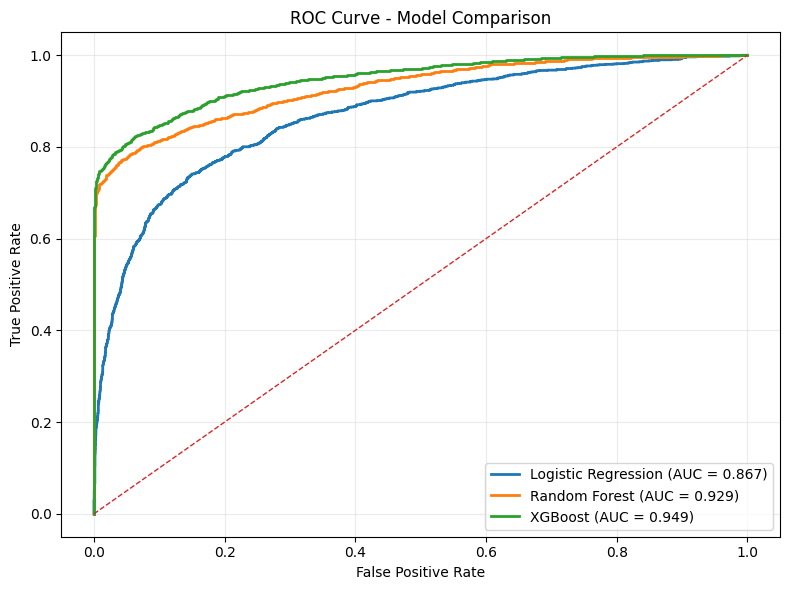

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Selection of Production Model

### Identifying the Strongest Metrics

In [ ]:
print("Best Recall:")
display(
    comparison_percent.loc[
        comparison_percent["Recall"].idxmax()
    ]
)

print("\nBest Precision:")
display(
    comparison_percent.loc[
        comparison_percent["Precision"].idxmax()
    ]
)

print("\nBest F1:")
display(
    comparison_percent.loc[
        comparison_percent["F1"].idxmax()
    ]
)

print("\nBest ROC-AUC:")
display(
    comparison_percent.loc[
        comparison_percent["ROC_AUC"].idxmax()
    ]
)

Best Recall:


,2
Model,XGBoost
Accuracy,92.011104
Precision,82.751092
Recall,80.183357
F1,81.446991
ROC_AUC,94.868205



Best Precision:


,1
Model,Random Forest
Accuracy,92.843924
Precision,93.050542
Recall,72.708039
F1,81.631037
ROC_AUC,92.93097



Best F1:


,1
Model,Random Forest
Accuracy,92.843924
Precision,93.050542
Recall,72.708039
F1,81.631037
ROC_AUC,92.93097



Best ROC-AUC:


,2
Model,XGBoost
Accuracy,92.011104
Precision,82.751092
Recall,80.183357
F1,81.446991
ROC_AUC,94.868205


### Save the Selection Decision

In [ ]:
PRODUCTION_MODEL_NAME = "XGBoost"

In [ ]:
model_selection_record = {
    "selected_model": PRODUCTION_MODEL_NAME,
    "selection_priority": [
        "Recall",
        "F1",
        "Precision",
        "ROC-AUC"
    ],
    "reason": (
        "Selected based on the observed trade-off between "
        "minority-class recall, precision, F1-score and ROC-AUC. "
        "Recall receives particular importance because identifying "
        "actual defaults is a key business objective."
    )
}

print(model_selection_record)

{'selected_model': 'XGBoost', 'selection_priority': ['Recall', 'F1', 'Precision', 'ROC-AUC'], 'reason': 'Selected based on the observed trade-off between minority-class recall, precision, F1-score and ROC-AUC. Recall receives particular importance because identifying actual defaults is a key business objective.'}


### Save the model

In [ ]:
import joblib
import os

if PRODUCTION_MODEL_NAME == "Logistic Regression":
    production_model = logistic_baseline

elif PRODUCTION_MODEL_NAME == "Random Forest":
    production_model = rf_tuned

elif PRODUCTION_MODEL_NAME == "XGBoost":
    production_model = xgb_tuned

else:
    raise ValueError(
        "Unknown production model."
    )

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "Checkpoints",
    "production_credit_risk_model.joblib"
)

joblib.dump(
    production_model,
    MODEL_PATH
)

print("Production model saved:")
print(MODEL_PATH)

Production model saved:
/content/drive/MyDrive/FINRISK_360/Checkpoints/production_credit_risk_model.joblib


## Save encoding metadata

In [ ]:
import json

encoding_metadata = {
    "loan_grade_mapping": {
        "A": 1,
        "B": 2,
        "C": 3,
        "D": 4,
        "E": 5,
        "F": 6,
        "G": 7
    },

    "cb_person_default_on_file_mapping": {
        "N": 0,
        "Y": 1
    },

    "loan_intent_one_hot_columns": [
        col for col in df.columns
        if col.startswith("loan_intent_")
    ],

    "home_ownership_one_hot_columns": [
        col for col in df.columns
        if col.startswith("home_ownership_")
    ],

    "credit_history_depth_columns": [
        col for col in df.columns
        if col.startswith("credit_history_depth_")
        and col != "credit_history_depth_tier"
    ],

    "model_features": (
        baseline_features
        if PRODUCTION_MODEL_NAME == "Logistic Regression"
        else rf_features
    ),

    "random_state": RANDOM_STATE
}

ENCODING_PATH = os.path.join(
    PROJECT_DIR,
    "Checkpoints",
    "credit_risk_encoding_metadata.json"
)

with open(
    ENCODING_PATH,
    "w"
) as f:
    json.dump(
        encoding_metadata,
        f,
        indent=4
    )

print("Encoding metadata saved:")
print(ENCODING_PATH)

Encoding metadata saved:
/content/drive/MyDrive/FINRISK_360/Checkpoints/credit_risk_encoding_metadata.json


## Save the model feature list

In [ ]:
FEATURE_PATH = os.path.join(
    PROJECT_DIR,
    "Checkpoints",
    "production_model_features.txt"
)

with open(
    FEATURE_PATH,
    "w"
) as f:
    for feature in encoding_metadata["model_features"]:
        f.write(feature + "\n")

print("Feature list saved:")
print(FEATURE_PATH)

Feature list saved:
/content/drive/MyDrive/FINRISK_360/Checkpoints/production_model_features.txt


## Save Evaluation Results

In [ ]:
RESULTS_PATH = os.path.join(
    PROJECT_DIR,
    "Checkpoints",
    "model_evaluation_comparison.csv"
)

comparison_percent.to_csv(
    RESULTS_PATH,
    index=False
)

print("Model comparison saved:")
print(RESULTS_PATH)

Model comparison saved:
/content/drive/MyDrive/FINRISK_360/Checkpoints/model_evaluation_comparison.csv


## Save all confusion matrices

In [ ]:
confusion_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "TN": [
        cm_logistic[0, 0],
        cm_rf[0, 0],
        cm_xgb[0, 0]
    ],

    "FP": [
        cm_logistic[0, 1],
        cm_rf[0, 1],
        cm_xgb[0, 1]
    ],

    "FN": [
        cm_logistic[1, 0],
        cm_rf[1, 0],
        cm_xgb[1, 0]
    ],

    "TP": [
        cm_logistic[1, 1],
        cm_rf[1, 1],
        cm_xgb[1, 1]
    ]
})

CM_RESULTS_PATH = os.path.join(
    PROJECT_DIR,
    "Checkpoints",
    "model_confusion_matrices.csv"
)

confusion_summary.to_csv(
    CM_RESULTS_PATH,
    index=False
)

display(confusion_summary)

print("Confusion matrices saved:")
print(CM_RESULTS_PATH)

,Model,TN,FP,FN,TP
0,Logistic Regression,3995,1071,300,1118
1,Random Forest,4989,77,387,1031
2,XGBoost,4829,237,281,1137


Confusion matrices saved:
/content/drive/MyDrive/FINRISK_360/Checkpoints/model_confusion_matrices.csv


## Verify the saved model

In [ ]:
loaded_production_model = joblib.load(
    MODEL_PATH
)

print(
    "Reloaded model type:",
    type(loaded_production_model).__name__
)

Reloaded model type: XGBClassifier


In [ ]:
reloaded_pred = loaded_production_model.predict(
    X_rf_test if PRODUCTION_MODEL_NAME != "Logistic Regression" else X_test
)

print("Reloaded model prediction successful.")
print("Number of predictions:", len(reloaded_pred))

Reloaded model prediction successful.
Number of predictions: 6484


## Credit & Customer Risk and Affordability Advisor

In [ ]:
import os
import pandas as pd
import numpy as np
import joblib

PROJECT_DIR = "/content/drive/MyDrive/FINRISK_360"
CLEANING_DIR = os.path.join(PROJECT_DIR, "Cleaning")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "Checkpoints")

MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "production_credit_risk_model.joblib"
)

model = joblib.load(MODEL_PATH)

print("Loaded model:")
print(type(model).__name__)

Loaded model:
XGBClassifier


In [ ]:
FEATURED_PATH = os.path.join(
    CLEANING_DIR,
    "credit_risk_fully_feature_engineered.csv"
)

df = pd.read_csv(FEATURED_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (32416, 33)


##Construct the XGBoost Feature Matrix

In [ ]:
rf_numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

In [ ]:
rf_derived_features = [
    "age_invalid_flag",
    "emp_length_invalid_flag",
    "emp_length_missing_flag",
    "loan_int_rate_missing_flag",
    "loan_grade_encoded",
    "cb_person_default_on_file_encoded",
    "grade_burden_interaction",
    "employment_stability_flag"
]

In [ ]:
rf_one_hot_features = [
    col for col in df.columns
    if col.startswith("loan_intent_")
    or col.startswith("home_ownership_")
]

In [ ]:
rf_credit_history_features = [
    col for col in df.columns
    if col.startswith("credit_history_depth_")
    and col != "credit_history_depth_tier"
]

In [ ]:
rf_features = (
    rf_numeric_features
    + rf_derived_features
    + rf_one_hot_features
    + rf_credit_history_features
)

print("Number of model features:", len(rf_features))

Number of model features: 23


### Final Feature Validation

In [ ]:
missing_features = [
    col for col in rf_features
    if col not in df.columns
]

print("Missing features:", missing_features)

X_all = df[rf_features].copy()

print("X_all shape:", X_all.shape)
print("Missing values:", X_all.isna().sum().sum())

Missing features: []
X_all shape: (32416, 23)
Missing values: 0


## Generate probability scores

In [ ]:
risk_probabilities = model.predict_proba(
    X_all
)[:, 1]

print("Risk scores generated.")
print("Number of scores:", len(risk_probabilities))

Risk scores generated.
Number of scores: 32416


In [ ]:
df["predicted_default_probability"] = risk_probabilities

print(
    df["predicted_default_probability"].describe()
)

count    32416.000000
mean         0.306737
std          0.332601
min          0.000032
25%          0.053099
50%          0.171964
75%          0.429370
max          0.999979
Name: predicted_default_probability, dtype: float64


## Build Risk Tiers

In [ ]:
def assign_risk_tier(default_probability):

    if pd.isna(default_probability):
        return np.nan

    if default_probability < 0.20:
        return "Low"

    elif default_probability < 0.35:
        return "Medium"

    elif default_probability <= 0.50:
        return "High"

    else:
        return "Severe"

In [ ]:
df["risk_tier"] = (
    df["predicted_default_probability"]
    .apply(assign_risk_tier)
)

In [ ]:
risk_categories = [
    "Low",
    "Medium",
    "High",
    "Severe"
]

df["risk_tier"] = pd.Categorical(
    df["risk_tier"],
    categories=risk_categories,
    ordered=True
)

In [ ]:
risk_distribution = (
    df["risk_tier"]
    .value_counts(sort=False)
    .rename_axis("risk_tier")
    .reset_index(name="applications")
)

risk_distribution["percentage"] = (
    risk_distribution["applications"]
    / len(df)
    * 100
)

display(
    risk_distribution.round(2)
)

,risk_tier,applications,percentage
0,Low,17555,54.16
1,Medium,5103,15.74
2,High,2717,8.38
3,Severe,7041,21.72


## Integrate the Affordability Advisor with the model

### Create a representative borrower profile

In [ ]:
reference_profile = {}

reference_profile["person_age"] = df["person_age"].median()
reference_profile["person_income"] = df["person_income"].median()
reference_profile["person_emp_length"] = df["person_emp_length"].median()
reference_profile["loan_amnt"] = df["loan_amnt"].median()
reference_profile["loan_int_rate"] = df["loan_int_rate"].median()
reference_profile["cb_person_cred_hist_length"] = (
    df["cb_person_cred_hist_length"].median()
)

reference_profile["person_home_ownership"] = (
    df["person_home_ownership"].mode()[0]
)

reference_profile["loan_intent"] = (
    df["loan_intent"].mode()[0]
)

reference_profile["loan_grade"] = (
    df["loan_grade"].mode()[0]
)

reference_profile["cb_person_default_on_file"] = (
    df["cb_person_default_on_file"].mode()[0]
)

In [ ]:
display(
    pd.DataFrame(
        [reference_profile]
    )
)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,cb_person_cred_hist_length,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,26.0,55000.0,4.0,8000.0,10.99,4.0,RENT,EDUCATION,A,N


### Model Input Function

In [ ]:
def build_advisor_input(
    annual_income,
    loan_amount,
    profile,
    model_features
):

    row = profile.copy()

    # Variables controlled by the advisor
    row["person_income"] = annual_income
    row["loan_amnt"] = loan_amount

    # Loan-to-income burden proxy
    row["loan_percent_income"] = (
        loan_amount / annual_income
    )

    # Existing grade encoding
    grade_mapping = {
        "A": 1,
        "B": 2,
        "C": 3,
        "D": 4,
        "E": 5,
        "F": 6,
        "G": 7
    }

    row["loan_grade_encoded"] = (
        grade_mapping[row["loan_grade"]]
    )

    # Binary default history
    row["cb_person_default_on_file_encoded"] = (
        1
        if row["cb_person_default_on_file"] == "Y"
        else 0
    )

    # Interaction feature
    row["grade_burden_interaction"] = (
        row["loan_grade_encoded"]
        * row["loan_percent_income"]
    )

    # Employment stability
    row["employment_stability_flag"] = (
        0
        if row["person_emp_length"] < 2
        else 1
    )

    # Missing/invalid flags for the reference profile
    row["age_invalid_flag"] = 0
    row["emp_length_invalid_flag"] = 0
    row["emp_length_missing_flag"] = 0
    row["loan_int_rate_missing_flag"] = 0

    # One-hot encoded features
    for col in rf_one_hot_features:
        row[col] = 0

    intent_col = (
        "loan_intent_"
        + row["loan_intent"]
    )

    if intent_col in row:
        row[intent_col] = 1

    ownership_col = (
        "home_ownership_"
        + row["person_home_ownership"]
    )

    if ownership_col in row:
        row[ownership_col] = 1

    # Credit history depth
    history = row["cb_person_cred_hist_length"]

    if history < 3:
        history_tier = "Shallow"
    elif history < 7:
        history_tier = "Moderate"
    elif history < 12:
        history_tier = "Deep"
    else:
        history_tier = "Very Deep"

    for col in rf_credit_history_features:
        row[col] = 0

    history_col = (
        "credit_history_depth_"
        + history_tier
    )

    if history_col in row:
        row[history_col] = 1

    input_df = pd.DataFrame([row])

    return input_df[model_features]

### Create the actual model-based Affordability Advisor

In [ ]:
SAFE_DEFAULT_THRESHOLD = 0.20

In [ ]:
def affordability_advisor_model_based(
    annual_income,
    requested_loan_amount,
    loan_amount_step=5000,
    safe_threshold=SAFE_DEFAULT_THRESHOLD
):

    if annual_income <= 0:
        raise ValueError(
            "Annual income must be greater than zero."
        )

    if requested_loan_amount < 0:
        raise ValueError(
            "Requested loan amount cannot be negative."
        )

    # Build a range of candidate loan amounts
    loan_amounts = np.arange(
        loan_amount_step,
        requested_loan_amount + loan_amount_step,
        loan_amount_step
    )

    results = []

    for loan_amount in loan_amounts:

        model_input = build_advisor_input(
            annual_income=annual_income,
            loan_amount=loan_amount,
            profile=reference_profile,
            model_features=rf_features
        )

        predicted_probability = model.predict_proba(
            model_input
        )[0, 1]

        loan_percent_income = (
            loan_amount / annual_income
        )

        results.append({
            "annual_income": annual_income,
            "loan_amount": loan_amount,
            "loan_percent_income": loan_percent_income,
            "loan_percent_income_percent": (
                loan_percent_income * 100
            ),
            "predicted_default_probability": (
                predicted_probability
            ),
            "predicted_default_probability_percent": (
                predicted_probability * 100
            ),
            "safe": (
                predicted_probability
                < safe_threshold
            )
        })

    results_df = pd.DataFrame(results)

    safe_results = results_df[
        results_df["safe"]
    ]

    if len(safe_results) > 0:
        maximum_safe_loan = (
            safe_results["loan_amount"].max()
        )
    else:
        maximum_safe_loan = 0

    return results_df, maximum_safe_loan

## Test and Execute some scenarios

In [ ]:
test_scenarios = [
    {
        "scenario": "Lower income - low loan",
        "income": 300000,
        "loan": 30000
    },

    {
        "scenario": "Lower income - high loan",
        "income": 300000,
        "loan": 150000
    },

    {
        "scenario": "Medium income - moderate loan",
        "income": 500000,
        "loan": 100000
    },

    {
        "scenario": "Medium income - high loan",
        "income": 500000,
        "loan": 250000
    },

    {
        "scenario": "Higher income - moderate loan",
        "income": 1000000,
        "loan": 200000
    },

    {
        "scenario": "High burden validation case",
        "income": 400000,
        "loan": 240000
    }
]

In [ ]:
scenario_summary = []

scenario_details = {}

for scenario in test_scenarios:

    results, maximum_safe = (
        affordability_advisor_model_based(
            annual_income=scenario["income"],
            requested_loan_amount=scenario["loan"]
        )
    )

    requested_row = results[
        results["loan_amount"]
        == scenario["loan"]
    ]

    if len(requested_row) > 0:

        requested_probability = (
            requested_row[
                "predicted_default_probability"
            ].iloc[0]
        )

    else:
        requested_probability = np.nan

    scenario_summary.append({
        "scenario": scenario["scenario"],
        "annual_income": scenario["income"],
        "requested_loan_amount": scenario["loan"],
        "loan_percent_income_percent": (
            scenario["loan"]
            / scenario["income"]
            * 100
        ),
        "predicted_default_probability_percent": (
            requested_probability * 100
        ),
        "maximum_safe_loan": maximum_safe
    })

    scenario_details[
        scenario["scenario"]
    ] = results

scenario_summary_df = pd.DataFrame(
    scenario_summary
)

display(
    scenario_summary_df.round(2)
)

,scenario,annual_income,requested_loan_amount,loan_percent_income_percent,predicted_default_probability_percent,maximum_safe_loan
0,Lower income - low loan,300000,30000,10.0,3.390000,30000
1,Lower income - high loan,300000,150000,50.0,93.959999,90000
2,Medium income - moderate loan,500000,100000,20.0,4.850000,100000
3,Medium income - high loan,500000,250000,50.0,93.959999,150000
4,Higher income - moderate loan,1000000,200000,20.0,4.850000,200000
5,High burden validation case,400000,240000,60.0,96.120003,120000


## Risk Tier Summary

In [ ]:
risk_summary = (
    df
    .groupby(
        "risk_tier",
        observed=False
    )
    .agg(
        applications=(
            "loan_status",
            "size"
        ),
        actual_defaults=(
            "loan_status",
            "sum"
        ),
        average_predicted_probability=(
            "predicted_default_probability",
            "mean"
        )
    )
    .reset_index()
)

risk_summary["percentage"] = (
    risk_summary["applications"]
    / len(df)
    * 100
)

risk_summary["actual_default_rate"] = (
    risk_summary["actual_defaults"]
    / risk_summary["applications"]
    * 100
)

display(
    risk_summary.round(2)
)

,risk_tier,applications,actual_defaults,average_predicted_probability,percentage,actual_default_rate
0,Low,17555,157,0.07,54.16,0.89
1,Medium,5103,377,0.27,15.74,7.39
2,High,2717,521,0.42,8.38,19.18
3,Severe,7041,6034,0.88,21.72,85.70


## Build the EWS Flag Pipeline

In [ ]:
model_features = list(model.feature_names_in_)

print("Number of model features:", len(model_features))

for i, feature in enumerate(model_features, 1):
    print(i, feature)

Number of model features: 23
1 person_age
2 person_income
3 person_emp_length
4 loan_amnt
5 loan_int_rate
6 loan_percent_income
7 cb_person_cred_hist_length
8 age_invalid_flag
9 emp_length_invalid_flag
10 emp_length_missing_flag
11 loan_int_rate_missing_flag
12 loan_grade_encoded
13 cb_person_default_on_file_encoded
14 grade_burden_interaction
15 employment_stability_flag
16 loan_intent_EDUCATION
17 loan_intent_HOMEIMPROVEMENT
18 loan_intent_MEDICAL
19 loan_intent_PERSONAL
20 loan_intent_VENTURE
21 home_ownership_OTHER
22 home_ownership_OWN
23 home_ownership_RENT


In [ ]:
missing_features = [
    feature
    for feature in model_features
    if feature not in df.columns
]

print("Missing features:", missing_features)

Missing features: []


### Create the Model Input

In [ ]:
X_check = df[model_features].copy()

In [ ]:
object_columns = X_check.select_dtypes(
    include=["object"]
).columns.tolist()

print("Object columns:", object_columns)

Object columns: []


### Create the EWS Function

In [ ]:
def early_warning_flag(
    application,
    model,
    model_features
):

    #  Prepare model input
    #  Explicitly create a dictionary for a single row to ensure correct dtype inference
    X_dict = {col: [application[col]] for col in model_features}
    X = pd.DataFrame(X_dict).astype(float)

    #  Model prediction

    predicted_probability = model.predict_proba(
        X
    )[0, 1]

    # Assign risk tier

    risk_tier = assign_risk_tier(
        predicted_probability
    )

    # Identify supporting factors

    risk_factors = []

    # Debt burden
    burden_tier = application[
        "debt_burden_tier"
    ]

    if burden_tier in [
        "High",
        "Severe"
    ]:

        risk_factors.append(
            f"{burden_tier} debt-burden tier"
        )

    # Loan grade
    grade = application[
        "loan_grade"
    ]

    if grade in [
        "D",
        "E",
        "F",
        "G"
    ]:

        risk_factors.append(
            f"Loan grade {grade}"
        )

    # Employment history
    employment_length = application[
        "person_emp_length"
    ]

    if employment_length < 2:

        risk_factors.append(
            "Short employment history (<2 years)"
        )

    # Apply final trigger

    elevated_model_risk = (
        risk_tier in [
            "High",
            "Severe"
        ]
    )

    supporting_driver = (
        len(risk_factors) > 0
    )

    ews_flag = (
        elevated_model_risk
        and supporting_driver
    )

    if ews_flag:

        flag_status = "FLAGGED"

    else:

        flag_status = "NOT FLAGGED"

    # Return result


    return {
        "predicted_default_probability":
            predicted_probability,

        "risk_tier":
            risk_tier,

        "ews_flag":
            flag_status,

        "risk_factors":
            (
                risk_factors
                if risk_factors
                else
                [
                    "No specified supporting risk driver"
                ]
            )
    }

In [ ]:
single_result = early_warning_flag(
    df.iloc[0],
    model,
    model_features
)

single_result

{'predicted_default_probability': np.float32(0.99407685),
 'risk_tier': 'Severe',
 'ews_flag': 'FLAGGED',
 'risk_factors': ['Severe debt-burden tier', 'Loan grade D']}

## Test EWS on a batch

### Create Test Features

In [ ]:
X_test= X_rf_test[model_features].copy()

In [ ]:
print(
    "X_test shape:",
    X_test.shape
)

X_test shape: (6484, 23)


### Generate Model Predictions

In [ ]:
test_probabilities = model.predict_proba(
    X_test
)[:, 1]

In [ ]:
test_risk_tiers = [
    assign_risk_tier(probability)
    for probability in test_probabilities
]

In [ ]:
ews_test_df = pd.DataFrame(
    {
        "index": X_test.index,

        "predicted_default_probability":
            test_probabilities,

        "risk_tier":
            test_risk_tiers
    },
    index=X_test.index
)

### Applying EWS to the batch

In [ ]:
ews_flags = []
risk_factors_list = []

In [ ]:
for idx in X_test.index:

    application = df.loc[idx] # Changed from X_test.loc[idx] to df.loc[idx]

    risk_tier = ews_test_df.loc[
        idx,
        "risk_tier"
    ]

    risk_factors = []

    # -----------------------------
    # Supporting factor 1:
    # Debt burden
    # -----------------------------

    if application[
        "debt_burden_tier"
    ] in ["High", "Severe"]:

        risk_factors.append(
            f"{application['debt_burden_tier']} debt-burden tier"
        )

    # -----------------------------
    # Supporting factor 2:
    # Loan grade
    # -----------------------------

    if application[
        "loan_grade"
    ] in ["D", "E", "F", "G"]:

        risk_factors.append(
            f"Loan grade {application['loan_grade']}"
        )

    # -----------------------------
    # Supporting factor 3:
    # Employment
    # -----------------------------

    if application[
        "person_emp_length"
    ] < 2:

        risk_factors.append(
            "Short employment history (<2 years)"
        )

    # -----------------------------
    # Model-risk condition
    # -----------------------------

    elevated_model_risk = (
        risk_tier in ["High", "Severe"]
    )

    # -----------------------------
    # Supporting-driver condition
    # -----------------------------

    supporting_driver = (
        len(risk_factors) > 0
    )

    # -----------------------------
    # Final EWS decision
    # -----------------------------

    flagged = (
        elevated_model_risk
        and supporting_driver
    )

    if flagged:

        ews_flags.append(
            "FLAGGED"
        )

    else:

        ews_flags.append(
            "NOT FLAGGED"
        )

    if risk_factors:

        risk_factors_list.append(
            risk_factors
        )

    else:

        risk_factors_list.append(
            ["No specified supporting risk driver"]
        )


In [ ]:
ews_test_df["ews_flag"] = ews_flags

ews_test_df["risk_factors"] = (
    risk_factors_list
)

### Add Validation Information

In [ ]:
ews_test_df["actual_loan_status"] = (
    df.loc[X_test.index, "loan_status"]
)

ews_test_df["debt_burden_tier"] = (
    df.loc[X_test.index, "debt_burden_tier"]
)

ews_test_df["loan_grade"] = (
    df.loc[X_test.index, "loan_grade"]
)

ews_test_df["person_emp_length"] = (
    df.loc[X_test.index, "person_emp_length"]
)

### Inspection

In [ ]:
display(
    ews_test_df.head(10)
)

,index,predicted_default_probability,risk_tier,ews_flag,risk_factors,actual_loan_status,debt_burden_tier,loan_grade,person_emp_length
21156,21156,0.491174,High,FLAGGED,[Loan grade E],0,Low,E,5.0
26854,26854,0.083865,Low,NOT FLAGGED,[Short employment history (<2 years)],1,Low,B,0.0
26333,26333,0.002477,Low,NOT FLAGGED,[No specified supporting risk driver],0,Low,B,10.0
24056,24056,0.013373,Low,NOT FLAGGED,[No specified supporting risk driver],0,Moderate,B,4.0
24947,24947,0.993310,Severe,FLAGGED,[High debt-burden tier],1,High,B,4.0
28808,28808,0.371604,High,NOT FLAGGED,[No specified supporting risk driver],0,Low,C,6.0
28361,28361,0.972683,Severe,FLAGGED,[Loan grade F],1,Moderate,F,4.0
8425,8425,0.352112,High,FLAGGED,[Loan grade D],0,Low,D,5.0
29094,29094,0.271307,Medium,NOT FLAGGED,[Short employment history (<2 years)],0,Low,C,0.0
30192,30192,0.089475,Low,NOT FLAGGED,[No specified supporting risk driver],0,Low,A,2.0


### Check Risk Tier Distribution

In [ ]:
risk_tier_distribution = (
    ews_test_df["risk_tier"]
    .value_counts()
    .reindex(
        [
            "Low",
            "Medium",
            "High",
            "Severe"
        ],
        fill_value=0
    )
)

display(
    risk_tier_distribution
)

,count
risk_tier,
Low,3516
Medium,1052
High,542
Severe,1374


In [ ]:
risk_tier_percentage = (
    risk_tier_distribution
    / len(ews_test_df)
    * 100
)

display(
    risk_tier_percentage.round(2)
)

,count
risk_tier,
Low,54.23
Medium,16.22
High,8.36
Severe,21.19


### Examine The Flagged Applications

In [ ]:
flagged_df = ews_test_df[
    ews_test_df["ews_flag"]
    == "FLAGGED"
].copy()

### Check Debt Burden among Flagged Applications

In [ ]:
flagged_burden_distribution = (
    flagged_df[
        "debt_burden_tier"
    ]
    .value_counts()
    .reindex(
        [
            "Low",
            "Moderate",
            "High",
            "Severe"
        ],
        fill_value=0
    )
)

display(
    flagged_burden_distribution
)

,count
debt_burden_tier,
Low,523
Moderate,400
High,331
Severe,43


### Check Loan Grade among Flagged Applications

In [ ]:
flagged_grade_distribution = (
    flagged_df[
        "loan_grade"
    ]
    .value_counts()
    .reindex(
        [
            "A",
            "B",
            "C",
            "D",
            "E",
            "F",
            "G"
        ],
        fill_value=0
    )
)

display(
    flagged_grade_distribution
)

,count
loan_grade,
A,104
B,200
C,169
D,591
E,169
F,48
G,16


### Check Short Employment Among Flagged Applications

In [ ]:
short_employment_flagged = (
    flagged_df[
        "person_emp_length"
    ] < 2
).sum()

short_employment_percentage = (
    short_employment_flagged
    / len(flagged_df)
    * 100
    if len(flagged_df) > 0
    else 0
)

print(
    "Flagged applications with <2 years employment:",
    short_employment_flagged
)

print(
    "Percentage:",
    round(
        short_employment_percentage,
        2
    ),
    "%"
)

Flagged applications with <2 years employment: 491
Percentage: 37.86 %


### Build Risk Driver Summary

In [ ]:
from collections import Counter

driver_counter = Counter()

for factors in flagged_df[
    "risk_factors"
]:

    for factor in factors:

        driver_counter[factor] += 1

In [ ]:
driver_summary = pd.DataFrame(
    driver_counter.items(),
    columns=[
        "risk_factor",
        "flagged_applications"
    ]
)

In [ ]:
display(
    driver_summary
)

,risk_factor,flagged_applications
0,Loan grade E,169
1,High debt-burden tier,331
2,Loan grade F,48
3,Loan grade D,591
4,Short employment history (<2 years),491
5,Loan grade G,16
6,Severe debt-burden tier,43


### Save EWS results

In [ ]:
CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "Checkpoints"
)

In [ ]:
EWS_RESULTS_PATH = os.path.join(
    CHECKPOINT_DIR,
    "credit_risk_early_warning_results.csv"
)

ews_test_df.to_csv(
    EWS_RESULTS_PATH,
    index=False
)

print(
    "Saved:",
    EWS_RESULTS_PATH
)

Saved: /content/drive/MyDrive/FINRISK_360/Checkpoints/credit_risk_early_warning_results.csv


### Save Validation Summary

In [ ]:
EWS_VALIDATION_PATH = os.path.join(
    CHECKPOINT_DIR,
    "early_warning_validation_summary.csv"
)

ews_test_df.to_csv(
    EWS_VALIDATION_PATH,
    index=False
)

print(
    "Saved:",
    EWS_VALIDATION_PATH
)

Saved: /content/drive/MyDrive/FINRISK_360/Checkpoints/early_warning_validation_summary.csv


### Save Trigger Rules

In [ ]:
import json

trigger_rules = {

    "system_type":
        "Point-in-time early warning classifier",

    "longitudinal_monitoring":
        False,

    "model_risk_tiers": {
        "Low":
            "<0.20",

        "Medium":
            "0.20 to <0.35",

        "High":
            "0.35 to 0.50",

        "Severe":
            ">0.50"
    },

    "ews_trigger": {

        "model_risk_requirement":
            [
                "High",
                "Severe"
            ],

        "supporting_driver_requirement":
            "At least one supporting risk driver"
    },

    "supporting_risk_drivers": [

        "Debt burden tier is High or Severe",

        "Loan grade is D, E, F, or G",

        "Employment history is less than 2 years"
    ],

    "target_used_for_trigger":
        False,

    "loan_status_used_for_validation_only":
        True,

    "explanation_method":
        "Rule-based supporting risk factors; SHAP deferred to Phase 12"
}

In [ ]:
EWS_RULES_PATH = os.path.join(
    CHECKPOINT_DIR,
    "early_warning_trigger_rules.json"
)

with open(
    EWS_RULES_PATH,
    "w"
) as f:

    json.dump(
        trigger_rules,
        f,
        indent=4
    )

print(
    "Saved:",
    EWS_RULES_PATH
)

Saved: /content/drive/MyDrive/FINRISK_360/Checkpoints/early_warning_trigger_rules.json


## Recovery Agent